Clean data loaded successfully! We have 125854 games to analyze.


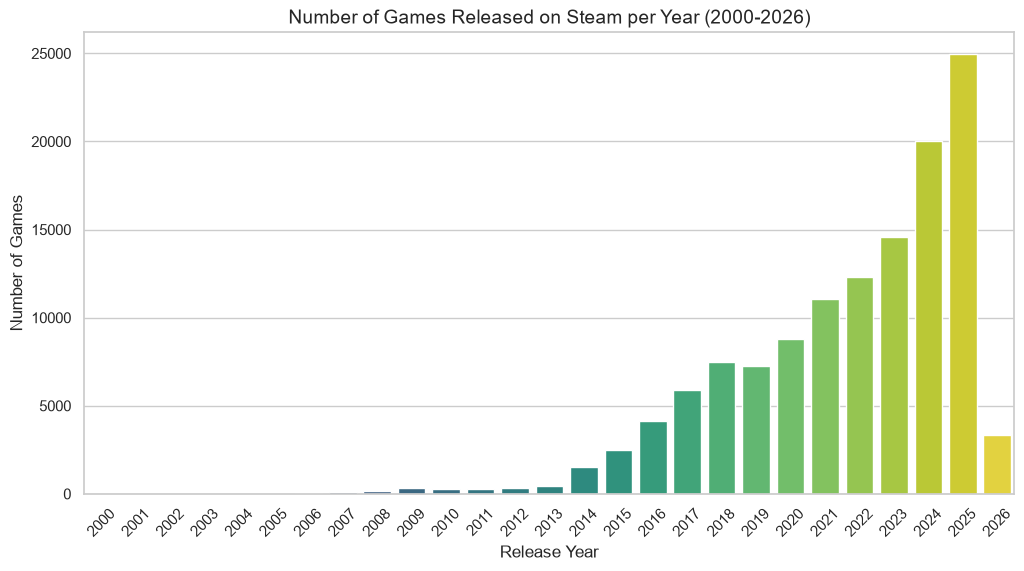

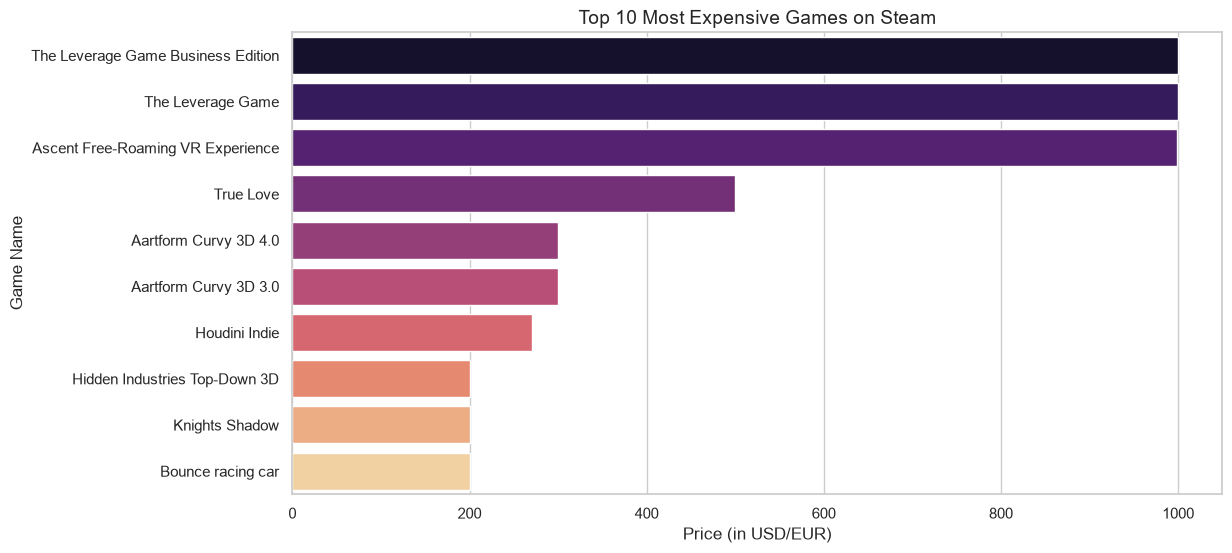

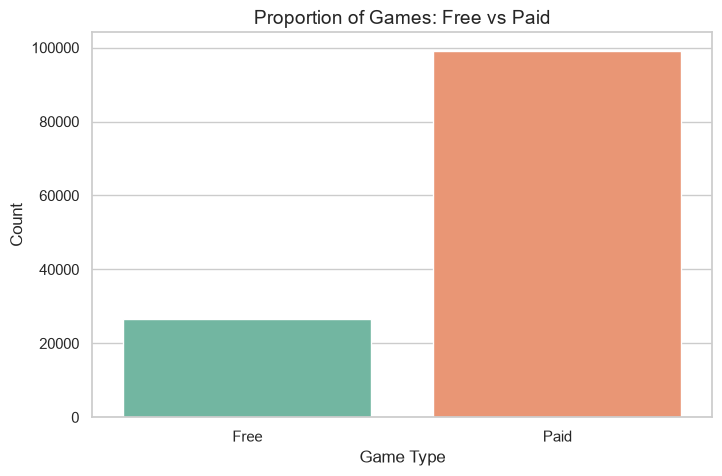

In [3]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")

df = pd.read_csv('games_clean.csv')
print("Clean data loaded successfully! We have", df.shape[0], "games to analyze.")

plt.figure(figsize=(12, 6))

df_anos = df[(df['Release year'] >= 2000) & (df['Release year'] <= 2026)]

ax = sns.countplot(data=df_anos, x='Release year', palette='viridis', hue='Release year', legend=False)
plt.xticks(rotation=45)
plt.title("Number of Games Released on Steam per Year (2000-2026)", fontsize=14)
plt.xlabel("Release Year", fontsize=12)
plt.ylabel("Number of Games", fontsize=12)

plt.show()

df_clean_names = df[df['Name'].apply(lambda x: str(x).isascii())]

top_10_expensive = df_clean_names.nlargest(10, 'Price')

plt.figure(figsize=(12,6))

sns.barplot(data=top_10_expensive, x='Price', y='Name', palette='magma', hue='Name', legend=False)
plt.title("Top 10 Most Expensive Games on Steam", fontsize=14)
plt.xlabel("Price (in USD/EUR)", fontsize=12)
plt.ylabel("Game Name", fontsize=12)

plt.show()

df['Type'] = df['Price'].apply(lambda x: 'Free' if x == 0 else 'Paid')

plt.figure(figsize=(8, 5))

sns.countplot(data=df, x='Type', palette='Set2', hue='Type', legend=False)
plt.title("Proportion of Games: Free vs Paid", fontsize=14)
plt.xlabel("Game Type", fontsize=12)
plt.ylabel("Count", fontsize=12)

plt.show()